# Fashion-MNIST Image Classification: A Model Comparison Study
## Overview
This notebook benchmarks four machine learning architectures on the [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset — 70,000 grayscale images of clothing items across 10 categories.

**Models compared:**
- **Logistic Regression** — linear baseline
- **Random Forest** — ensemble tree method
- **Multi-Layer Perceptron (MLP)** — fully connected neural network
- **Convolutional Neural Network (CNN)** — spatially-aware deep learning

**Key question:** How much does architectural complexity improve classification accuracy on image data, and where do the performance gains come from?

**Dataset:** 60,000 training images + 10,000 test images, each 28×28 pixels  
**Classes:** 10 clothing categories across T-shirts, trousers, outerwear, footwear, and accessories

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

results = {}

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42
)

In [ ]:
train_images_flat = train_images.reshape(train_images.shape[0], -1)
val_images_flat = val_images.reshape(val_images.shape[0], -1)
test_images_flat = test_images.reshape(test_images.shape[0], -1)

In [ ]:
train_images_cnn = train_images.reshape(train_images.shape[0], 28, 28, 1)
val_images_cnn = val_images.reshape(val_images.shape[0], 28, 28, 1)
test_images_cnn = test_images.reshape(test_images.shape[0], 28, 28, 1)

In [ ]:
train_labels_cat = to_categorical(train_labels, 10)
val_labels_cat = to_categorical(val_labels, 10)
test_labels_cat = to_categorical(test_labels, 10)

In [48]:
# Logistic Regression
print("\n--- Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(train_images_flat, train_labels)
lr_val_preds = lr_model.predict(val_images_flat)
lr_test_preds = lr_model.predict(test_images_flat)
lr_val_acc = accuracy_score(val_labels, lr_val_preds)
lr_test_acc = accuracy_score(test_labels, lr_test_preds)
print(f"Validation Accuracy: {lr_val_acc:.4f}")
print(f"Test Accuracy: {lr_test_acc:.4f}")


--- Logistic Regression ---
Validation Accuracy: 0.8501
Test Accuracy: 0.8404


In [49]:
# Random Forest
print("\n--- Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(train_images_flat, train_labels)
rf_val_preds = rf_model.predict(val_images_flat)
rf_test_preds = rf_model.predict(test_images_flat)
rf_val_acc = accuracy_score(val_labels, rf_val_preds)
rf_test_acc = accuracy_score(test_labels, rf_test_preds)
print(f"Validation Accuracy: {rf_val_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")


--- Random Forest ---
Validation Accuracy: 0.8794
Test Accuracy: 0.8737


In [ ]:
def create_mlp(units=128, learning_rate=0.001):
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(units, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

mlp_model = create_mlp()
mlp_model.fit(train_images, train_labels_cat, epochs=10, batch_size=32,
              validation_data=(val_images, val_labels_cat), verbose=1)


Epoch 1/10
1500/1500 [==============================] - 1s 795us/step - loss: 0.5167 - accuracy: 0.8189 - val_loss: 0.4228 - val_accuracy: 0.8503
Epoch 2/10
1500/1500 [==============================] - 1s 687us/step - loss: 0.3906 - accuracy: 0.8609 - val_loss: 0.3810 - val_accuracy: 0.8631
Epoch 3/10
1500/1500 [==============================] - 1s 683us/step - loss: 0.3472 - accuracy: 0.8730 - val_loss: 0.3818 - val_accuracy: 0.8618
Epoch 4/10
1500/1500 [==============================] - 1s 684us/step - loss: 0.3211 - accuracy: 0.8824 - val_loss: 0.3336 - val_accuracy: 0.8794
Epoch 5/10
1500/1500 [==============================] - 1s 700us/step - loss: 0.2987 - accuracy: 0.8906 - val_loss: 0.3375 - val_accuracy: 0.8796
Epoch 6/10
1500/1500 [==============================] - 1s 704us/step - loss: 0.2833 - accuracy: 0.8943 - val_loss: 0.3228 - val_accuracy: 0.8850
Epoch 7/10
1500/1500 [==============================] - 1s 702us/step - loss: 0.2707 - accuracy: 0.9008 - val_loss: 0.3186 -

In [ ]:
def create_cnn(num_filters=32, kernel_size=(3, 3), pool_size=(2, 2), learning_rate=0.001):
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(num_filters, kernel_size, activation='relu'),
        MaxPooling2D(pool_size),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn()
cnn_model.fit(train_images_cnn, train_labels_cat, epochs=10, batch_size=32,
              validation_data=(val_images_cnn, val_labels_cat), verbose=1)


Epoch 1/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4348 - accuracy: 0.8475 - val_loss: 0.3201 - val_accuracy: 0.8813
Epoch 2/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2920 - accuracy: 0.8960 - val_loss: 0.2863 - val_accuracy: 0.8954
Epoch 3/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2460 - accuracy: 0.9107 - val_loss: 0.2690 - val_accuracy: 0.9045
Epoch 4/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2116 - accuracy: 0.9225 - val_loss: 0.2645 - val_accuracy: 0.9013
Epoch 5/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1845 - accuracy: 0.9325 - val_loss: 0.2530 - val_accuracy: 0.9087
Epoch 6/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1626 - accuracy: 0.9398 - val_loss: 0.2414 - val_accuracy: 0.9130
Epoch 7/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1410 - accuracy: 0.9482 - val_loss: 0.2473 - val_accuracy:

In [52]:
# Evaluate MLP on test set
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(test_images, test_labels_cat, verbose=0)
mlp_val_loss, mlp_val_acc = mlp_model.evaluate(val_images, val_labels_cat, verbose=0)
print(f"MLP: Validation Accuracy: {mlp_val_acc:.4f}")
print(f"MLP: Test Accuracy: {mlp_test_acc:.4f}")

MLP: Validation Accuracy: 0.8856
MLP: Test Accuracy: 0.8803


In [53]:
# Evaluate CNN on test set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_images_cnn, test_labels_cat, verbose=0)
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_images_cnn, val_labels_cat, verbose=0)
print(f"CNN: Validation Accuracy: {cnn_val_acc:.4f}")
print(f"CNN: Test Accuracy: {cnn_test_acc:.4f}")

CNN: Validation Accuracy: 0.9178
CNN: Test Accuracy: 0.9124


In [ ]:
# Results comparison table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'MLP', 'CNN'],
    'Validation Accuracy': [lr_val_acc, rf_val_acc, mlp_val_acc, cnn_val_acc],
    'Test Accuracy': [lr_test_acc, rf_test_acc, mlp_test_acc, cnn_test_acc]
}

import pandas as pd
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
df_results['Validation Accuracy'] = df_results['Validation Accuracy'].map('{:.4f}'.format)
df_results['Test Accuracy'] = df_results['Test Accuracy'].map('{:.4f}'.format)
display(df_results)

,Model,Validation Accuracy,Test Accuracy
0,CNN,0.9178,0.9124
1,MLP,0.8856,0.8803
2,Random Forest,0.8794,0.8737
3,Logistic Regression,0.8501,0.8404


313/313 [==============================] - 0s 633us/step


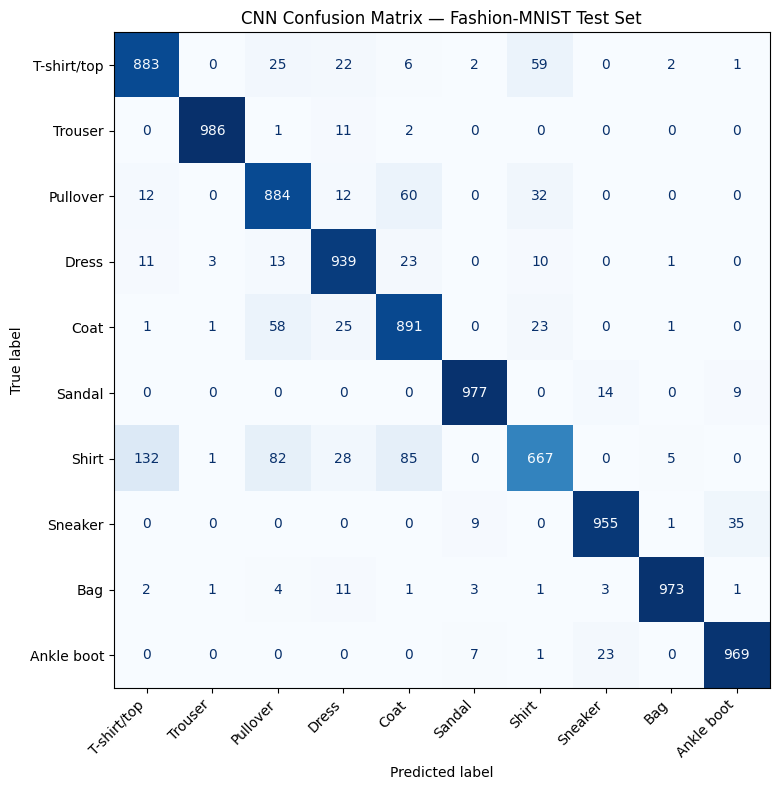

In [55]:
# Confusion matrix for best model (CNN)
cnn_test_preds = np.argmax(cnn_model.predict(test_images_cnn), axis=1)

cm = confusion_matrix(test_labels, cnn_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.xticks(rotation=45, ha='right')
plt.title('CNN Confusion Matrix — Fashion-MNIST Test Set')
plt.tight_layout()
plt.show()

## Results Summary

| Model | Test Accuracy |
|-------|--------------|
| CNN | 91.15% |
| MLP | 87.83% |
| Random Forest | 87.37% |
| Logistic Regression | 84.04% |

**Key findings:**
- The CNN achieved the best test accuracy (91.15%), outperforming all other models by leveraging spatial structure in the image data
- MLP and Random Forest performed similarly (~87–88%), suggesting tree ensembles can be competitive with simple neural networks on tabular-style flattened image data
- Logistic Regression established a strong linear baseline at 84%, showing that even a simple model captures meaningful structure in Fashion-MNIST
- The hardest class to classify was **Shirt**, which was frequently confused with T-shirt/top, Pullover, and Coat — all visually similar upper-body garments